<a href="https://colab.research.google.com/github/shinyunji3236-cmyk/2026_datascience_teamproject/blob/main/Data_Science_Team_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Exploration

In [1]:
import os
import pandas as pd
import numpy as np

# 'huggingface' 사이트에 로그인 후 데이터 받아오기
df = pd.read_csv("hf://datasets/meal-bbang/Korean_message/lgaidataset.csv")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [2]:
# 데이터 잘 받아와졌나 확인하기

print("DataFrame Info:")
df.info()
print("\nFirst 5 Rows:")
print(df.head())
print("\nData Columns:")
print(df.columns)

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19009 entries, 0 to 19008
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   index    16309 non-null  float64
 1   content  19009 non-null  object 
 2   class    19009 non-null  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 445.7+ KB

First 5 Rows:
   index                                            content  class
0    2.0  엄마 나 폰이 망가져서 수리맡기고 컴퓨터 문자나라로 메시지 보내고 있어 엄마 지금 바뻐?      2
1    2.0  [국외발신]\n[코인원]\n고객님계정이\n해외IP에서\n로그인되였습니다.해외IP차단...      2
2    2.0  엄마 입금받을수있는\n은행계좌번호\n하나랑 계좌등록\n본인인증땜에\n계좌 3자리\n...      2
3    3.0  엄마 바빠?나지금\n핸드폰 고장나서 매장에 수리맡기고\n급한대로 예전에\n내명의로 ...      2
4    5.0  엄마~ 바빠?\n엄마 나 급한 일이 좀 생겨서…\n지금 98만원만 입금해 줄 수 있...      2

Data Columns:
Index(['index', 'content', 'class'], dtype='object')


In [3]:
# 라이브러리 및 한글 폰트 설치 (Colab 내 한글 깨짐 현상을 해결)

!sudo apt-get install -y fonts-nanum
!fc-cache -fv
!rm ~/.cache/matplotlib -rf

import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (33.5 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and direct

▶ 결측치 확인
index      2700
content       0
class         0
dtype: int64

▶ 라벨 비율 확인 (%)
class
2    55.4
1    30.4
3    14.2
Name: proportion, dtype: float64


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/loca

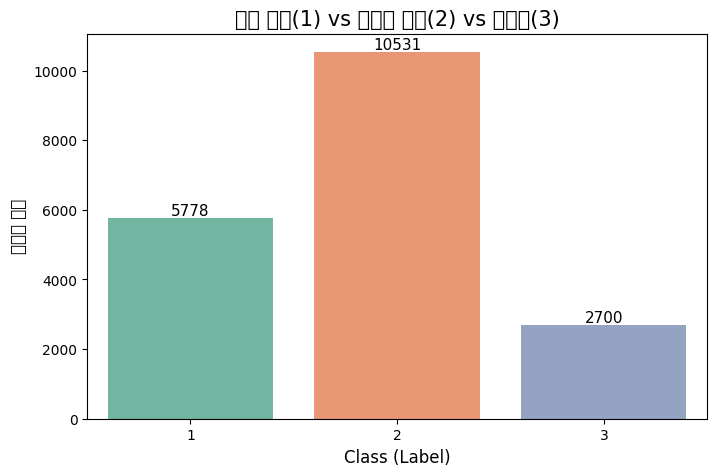

In [4]:
# 결측치 확인
print("▶ 결측치 확인")
print(df.isnull().sum())

# 확인 결과 단순한 행 번호(index)에 2700개의 결측치(상관없는 값) 존재
# 확인해보니 미분류 값에 id 번호가 안 적혀있어 index가 결측치 처리 된 듯
# 어차피 index값은 분석과 상관없어서 preprocessing 할 때 df = df.drop(columns=['index'])로 삭제 가능
# 우리가 분석해야 할 실제 문자 메시지 내용(content) 결측치 0개
# 스미싱 여부를 알려주는 정답 라벨(class) 결측치 0개
# 여기서 말하는 결측치는 빈칸이 있나, 정답 라벨에 다른 숫자가 들어있나를 확인한 것

# 라벨(1: 정상, 2: 스미싱, 3: 미분류) 분포 확인
print("\n▶ 라벨 비율 확인 (%)")
label_counts = df['class'].value_counts(normalize=True) * 100
print(label_counts.round(2))

# 확인 결과 스미싱이 55.4%, 정상이 30.4%, 미분류가 14.2%
# 14% 미분류된 데이터는 삭제할지 preprocessing을 거쳐서 학습에 쓸지 추후 결정

# 라벨 분포 시각화
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
ax = sns.countplot(x='class', hue='class', data=df, palette='Set2', legend=False)
plt.title('정상 문자(1) vs 스미싱 문자(2) vs 미분류(3)', fontsize=15)
plt.xlabel('Class (Label)', fontsize=12)
plt.ylabel('데이터 개수', fontsize=12)

# 막대 그래프 위에 정확한 개수 표시
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', fontsize=11, xytext=(0, 5),
                textcoords='offset points')
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48296 (\N{HANGUL SYLLABLE BEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/loc

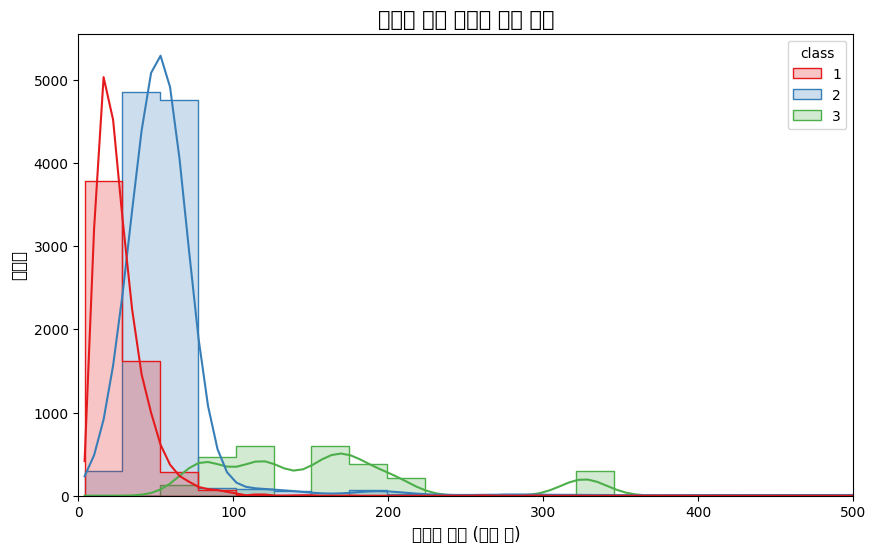

In [5]:
# 문자 메시지 길이에 따른 분포 확인
# 메시지 내용이 담긴 실제 column명 'content'를 사용
df['text_length'] = df['content'].astype(str).apply(len)

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='text_length', hue='class', bins=50, kde=True, palette='Set1', element="step")
plt.title('라벨별 문자 메시지 길이 분포', fontsize=15)
plt.xlabel('메시지 길이 (글자 수)', fontsize=12)
plt.ylabel('빈도수', fontsize=12)
plt.xlim(0, 500)
plt.show()

# 확인 결과, 대부분 메시지 길이는 100자 이하로 짧다
# 스미싱 문자가 일반 문자보다 상대적으로 길다
# 미분류된 메시지의 경우 메시지 길이가 100자부터 300자 이상까지 매우 불규칙적으로 퍼져있다. 이상치 처리 필요할 듯!

# 정상 문자와 스미싱 문자를 구분할 때, 메시지의 글자수를 feature로 쓸 수 있을 듯

In [6]:
# 한국어 형태소 분석기 설치
!pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 19.5 MB/s eta 0:00:00


/tmp/ipykernel_4635/3912707355.py:50: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4635/3912707355.py:50: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4635/3912707355.py:50: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4635/3912707355.py:50: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4635/3912707355.py:50: UserWarning: Glyph 51676 (\N{HANGUL SYLLABLE JJA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4635/3912707355.py:50: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4635/3912707355.py:50: UserWarning: Glyph 46988 (\N{HANGUL SYLLABLE RAM}) missing from font(s) DejaVu Sans.
  plt.tight_layo

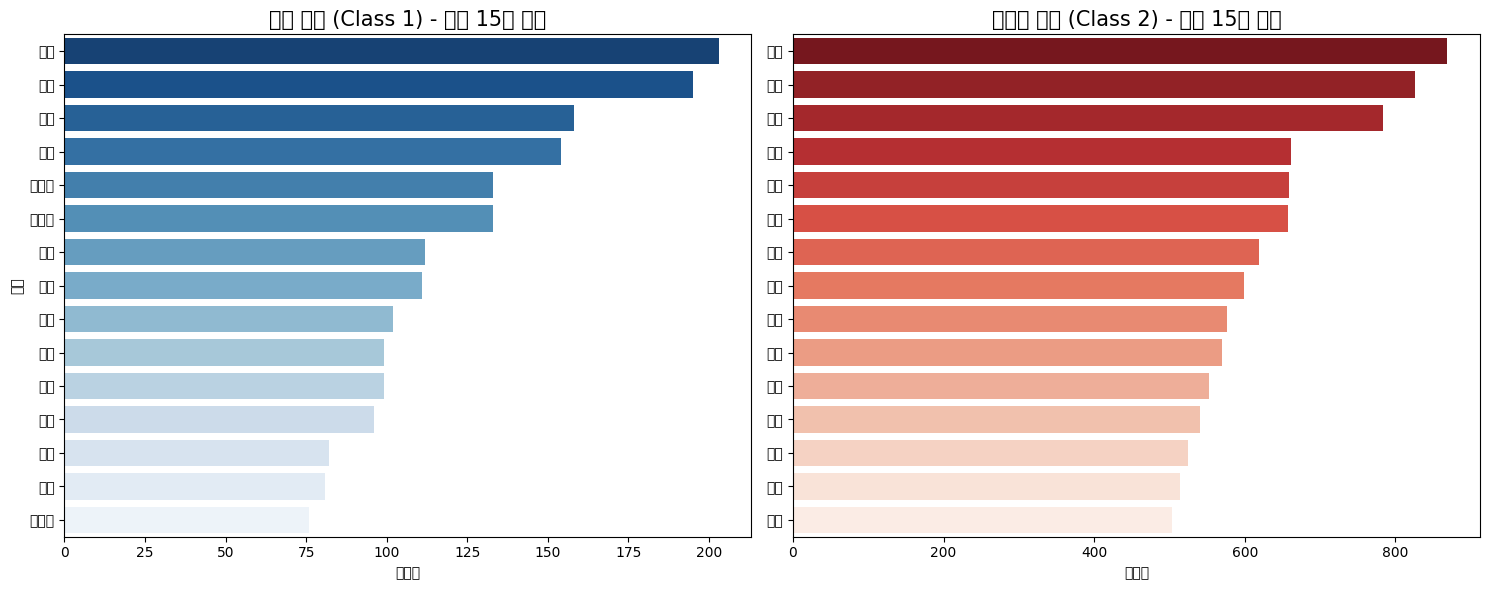

In [7]:
# 특정 단어가 라벨 별로 얼마나 자주 등장하는지 확인 (우선 상위 15개만)

from konlpy.tag import Okt
from collections import Counter

# 형태소 분석기 초기화
okt = Okt()

# 명사 추출 및 빈도수 계산 함수 정의
def get_top_nouns(text_series, top_n=15):
    all_nouns = []
    # 각 문자 메시지에서 명사만 추출
    for text in text_series.astype(str):
        nouns = okt.nouns(text)
        # 1글자 단어는 의미를 파악하기 어려우므로 제외 (예: '것', '수', '등')
        nouns = [word for word in nouns if len(word) > 1]
        all_nouns.extend(nouns)

    # 단어별 빈도수 계산 후 상위 N개 반환
    counter = Counter(all_nouns)
    return counter.most_common(top_n)

# 클래스별로 데이터 분리 및 빈도수 계산
# class 1 (정상 문자), class 2 (스미싱 문자)
normal_texts = df[df['class'] == 1]['content']
smishing_texts = df[df['class'] == 2]['content']

top_normal_words = get_top_nouns(normal_texts, 15)
top_smishing_words = get_top_nouns(smishing_texts, 15)

# 데이터프레임으로 변환
df_normal = pd.DataFrame(top_normal_words, columns=['Word', 'Count'])
df_smishing = pd.DataFrame(top_smishing_words, columns=['Word', 'Count'])

# 시각화 (두 개의 그래프를 나란히 배치)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 정상 문자 단어 빈도 그래프
sns.barplot(x='Count', y='Word', data=df_normal, ax=axes[0], palette='Blues_r', hue='Word', legend=False)
axes[0].set_title('정상 문자 (Class 1) - 상위 15개 명사', fontsize=15)
axes[0].set_xlabel('빈도수')
axes[0].set_ylabel('단어')

# 스미싱 문자 단어 빈도 그래프
sns.barplot(x='Count', y='Word', data=df_smishing, ax=axes[1], palette='Reds_r', hue='Word', legend=False)
axes[1].set_title('스미싱 문자 (Class 2) - 상위 15개 명사', fontsize=15)
axes[1].set_xlabel('빈도수')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# Data Preprocessing

In [8]:
import pandas as pd
import re
import numpy as np
from konlpy.tag import Okt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack
from IPython.display import display

# 미분류 데이터(3) 제거 및 정상(1)/스미싱(2)만 남기기
df = df[df['class'].isin([1, 2])].reset_index(drop=True)

# 분석에 불필요한 index 컬럼 삭제 (존재할 경우)
if 'index' in df.columns:
    df = df.drop(columns=['index'])

print("▶ 미분류(3) 데이터 및 불필요한 컬럼 제거 완료")
print(f"  - 현재 데이터 크기: {df.shape}")
display(df.head(5))


▶ 미분류(3) 데이터 및 불필요한 컬럼 제거 완료
  - 현재 데이터 크기: (16309, 3)


,content,class,text_length
0,엄마 나 폰이 망가져서 수리맡기고 컴퓨터 문자나라로 메시지 보내고 있어 엄마 지금 바뻐?,2,49
1,[국외발신]\n[코인원]\n고객님계정이\n해외IP에서\n로그인되였습니다.해외IP차단...,2,64
2,엄마 입금받을수있는\n은행계좌번호\n하나랑 계좌등록\n본인인증땜에\n계좌 3자리\n...,2,51
3,엄마 바빠?나지금\n핸드폰 고장나서 매장에 수리맡기고\n급한대로 예전에\n내명의로 ...,2,104
4,엄마~ 바빠?\n엄마 나 급한 일이 좀 생겨서…\n지금 98만원만 입금해 줄 수 있...,2,49


In [9]:
# 문자 메시지에는 특수문자, 의미 없는 이모티콘, 공백, 국문/영문이 복잡하게 섞여 있음.
# 특히 스미싱 문자는 [Web발신], (광고) 같은 패턴이나 특수 기호가 많으므로 이를 정규표현식(re)으로 정제.

# 텍스트 정제-한글, 영문, 숫자와 필수 특수기호만 남기기

def clean_text(text):
    if not isinstance(text, str):
        text = str(text)
    # 한글, 영문, 숫자, 그리고 스미싱에 자주 쓰이는 특수문자([], (), /, ., :)만 남기고 제거
    text = re.sub(r'[^가-힣a-zA-Z0-9\[\]\(\)\/\.\:]', ' ', text)
    # 연속된 공백 하나로 줄이기
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned_content'] = df['content'].apply(clean_text)

print("▶ 텍스트 정제(불필요한 특수문자 및 공백 제거) 완료")
print("  - [비교] 원본 데이터 vs 정제된 데이터")
display(df[['content', 'cleaned_content']].head(3))

▶ 텍스트 정제(불필요한 특수문자 및 공백 제거) 완료
  - [비교] 원본 데이터 vs 정제된 데이터


,content,cleaned_content
0,엄마 나 폰이 망가져서 수리맡기고 컴퓨터 문자나라로 메시지 보내고 있어 엄마 지금 바뻐?,엄마 나 폰이 망가져서 수리맡기고 컴퓨터 문자나라로 메시지 보내고 있어 엄마 지금 바뻐
1,[국외발신]\n[코인원]\n고객님계정이\n해외IP에서\n로그인되였습니다.해외IP차단...,[국외발신] [코인원] 고객님계정이 해외IP에서 로그인되였습니다.해외IP차단해주세요...
2,엄마 입금받을수있는\n은행계좌번호\n하나랑 계좌등록\n본인인증땜에\n계좌 3자리\n...,엄마 입금받을수있는 은행계좌번호 하나랑 계좌등록 본인인증땜에 계좌 3자리 비밀번호까...


In [10]:
# 이상치 제거-글자 수가 0이거나 미만인 데이터(정제 후 빈 칸이 된 데이터), 혹은 데이터의 99%가 포함되는 범위를 벗어난 너무 긴 메시지(예: 500자 초과)는 학습에서 제외
# 정제 후 글자 수 다시 계산
df['text_length'] = df['cleaned_content'].apply(len)

before_len = len(df)

# 글자 수가 너무 짧거나(내용 없음) 500자를 초과하는 극단적 이상치 제거
df = df[(df['text_length'] > 0) & (df['text_length'] <= 500)].reset_index(drop=True)

print("▶ 이상치 제거 완료")
print(f"  - 제거된 데이터 개수: {before_len - len(df)}개")
print(f"  - 현재 데이터 크기: {df.shape}")

▶ 이상치 제거 완료
  - 제거된 데이터 개수: 152개
  - 현재 데이터 크기: (16157, 4)


In [11]:
# 토큰화(Tokenization) 및 불용어 제거-명사 분석 시 상위에 나왔던 단어 중 '회원님', '고객님'처럼 정상/스미싱 모두에 너무 흔하게 쓰여서 분별력이 없는 단어나, 의미 없는 조사들을 리스트로 만들어 제외

# # 불용어 리스트 예시-추가 확장 필요
# stopwords = ['의', '가', '이', '은', '들', '는', '좀', '잘', '걍', '과', '도', '를', '으로', '자', '에', '와', '한', '하다']

# def tokenize_and_remove_stopwords(text):
#     # 명사뿐만 아니라 동사, 형용사까지 형태소 분석을 원하면 okt.morphs() 사용
#     # 단어 고유의 의미를 살리려면 stem=True 옵션 추가 가능
#     tokens = okt.nouns(text)
#     # 1글자 제어 및 불용어 제거
#     meaningful_tokens = [word for word in tokens if len(word) > 1 and word not in stopwords]
#     return ' '.join(meaningful_tokens) # 단어들을 공백으로 이어붙인 문자열 반환

# print("▶ 토큰화 및 불용어 제거")
# df['tokenized_content'] = df['cleaned_content'].apply(tokenize_and_remove_stopwords)

# print("  - [비교] 정제된 텍스트 vs 토큰화된 텍스트")
# display(df[['cleaned_content', 'tokenized_content']].head(10))

# 불용어(stopwords) 리스트
# 모델 학습에 큰 의미가 없거나 너무 자주 등장해서 분류에 도움이 적은 단어들을 제거하기 위한 목록
stopwords = [
    '의', '가', '이', '은', '들', '는', '좀', '잘', '걍',
    '과', '도', '를', '으로', '자', '에', '와', '한',
    '하다', '되다', '있다', '없다', '회원님', '고객님'
]

# 문자 메시지 하나를 입력받아 의미 있는 토큰만 남기는 함수
def tokenize_and_remove_stopwords(text):

    # Okt 형태소 분석기로 단어와 품사를 함께 추출
    # stem=True는 동사/형용사를 기본형에 가깝게 바꿔줌
    # 예: "신청했습니다" → "신청하다", "확인하세요" → "확인하다"
    # 스미싱에서는 행동 유도 표현이 중요할 수 있기 때문 - (확인하세요, 접속하세요, 클릭하세요 등)
    tokens = okt.pos(text, stem=True)

    # tokens의 형태 예시:
    # [('신규', 'Noun'), ('대출', 'Noun'), ('신청', 'Noun'), ('가능하다', 'Adjective')]

    meaningful_tokens = [
        word for word, pos in tokens

        # 사용할 품사만 선택
        # Noun: 명사
        # Verb: 동사
        # Adjective: 형용사
        # Alpha: 영어 단어, 예: url, http, com 등
        if pos in ['Noun', 'Verb', 'Adjective', 'Alpha']

        # 한 글자짜리 토큰은 대부분 의미가 약하므로 제거
        # 예: 내, 너, 그, 수, 것 (앱, 돈, 문 같은 의미 있는 글자도 존재하나, 잡음을 줄이는 데 도움이 됨)
        and len(word) > 1

        # 불용어 리스트에 들어 있는 단어 제거
        and word not in stopwords
    ]

    # 추출된 토큰들을 다시 하나의 문자열로 합침
    # TF-IDF는 문자열 입력을 받기 때문에 리스트가 아니라 문자열로 변환해야 함
    return ' '.join(meaningful_tokens)

print("▶ 토큰화 및 불용어 제거")

# cleaned_content 컬럼의 각 문자 메시지에 위 함수를 적용
# 결과는 tokenized_content라는 새 컬럼에 저장
df['tokenized_content'] = df['cleaned_content'].apply(tokenize_and_remove_stopwords)

print("  - [비교] 정제된 텍스트 vs 토큰화된 텍스트")

# 전처리 전후를 비교하기 위해 앞의 10개 행 출력
display(df[['cleaned_content', 'tokenized_content']].head(10))

▶ 토큰화 및 불용어 제거
  - [비교] 정제된 텍스트 vs 토큰화된 텍스트


,cleaned_content,tokenized_content
0,엄마 나 폰이 망가져서 수리맡기고 컴퓨터 문자나라로 메시지 보내고 있어 엄마 지금 바뻐,엄마 망가지다 수리 맡다 컴퓨터 문자 메시지 보내다 엄마 지금 바쁘다
1,[국외발신] [코인원] 고객님계정이 해외IP에서 로그인되였습니다.해외IP차단해주세요...,국외 발신 코인 고객 계정 해외 IP 로그인 해외 IP 차단 해주다
2,엄마 입금받을수있는 은행계좌번호 하나랑 계좌등록 본인인증땜에 계좌 3자리 비밀번호까...,엄마 입금 받다 은행 계좌 번호 하나 계좌 등록 본인 인증 계좌 자리 비밀번호 보내다
3,엄마 바빠 나지금 핸드폰 고장나서 매장에 수리맡기고 급한대로 예전에 내명의로 가입해...,엄마 바쁘다 지금 핸드폰 고장 나서다 매장 수리 맡다 급하다 예전 명의 가입 놧던 ...
4,엄마 바빠 엄마 나 급한 일이 좀 생겨서 지금 98만원만 입금해 줄 수 있어 C6,엄마 바쁘다 엄마 급하다 생기다 지금 입금
5,엄마 나 폰고장나서 수리 맡기고 문자나 가입한거로 문자하고 있어 피씨용이라 문자만가...,엄마 고장 나서다 수리 맡다 문자 가입 문자 피씨 용이 문자 가능하다 문자 주다 알...
6,엄마 나 핸드폰 고장나서 서비스 맡기고 문자나라 접해서 문자하는거야 문자보면 답줘 ...,엄마 핸드폰 고장 나서다 서비스 맡다 문자 문자 문자 보다 주다 부탁 그렇다 엄마 ...
7,[web 발신] 아빠 나지금폰 액정나가서 않되 01059680026 이번호로 톡추가...,web 발신 아빠 지금 액정 나가다 않다 이번 호로 추가 주다 통화 안되다
8,엄마 나 핸드폰 고장나서 수리맡기고 컴터로 새카톡만들엇어 010 이번호로 카톡추가하...,엄마 핸드폰 고장 나서다 수리 맡다 컴터 카톡 만들다 엇어 이번 호로 카톡 추가 주다
9,엄마 바빠 나 지금 핸드폰 고장나서 매장에 수리맡기고 급한대로 예전에 내명의로 가입...,엄마 바쁘다 지금 핸드폰 고장 나서다 매장 수리 맡다 급하다 예전 명의 가입 문자 ...


In [12]:
# 중복 문자 확인 및 제거
# cleaned_content 기준으로도 가능하지만 content 기준이 데이터를 날릴 위험이 적음

# drop_duplicates() 전에 중복 개수를 먼저 확인

print("중복 제거 전 데이터 크기:", df.shape)

duplicate_count = df.duplicated(subset='content').sum()
print("중복 행 수(content 기준):", duplicate_count)

duplicated_rows = df[df.duplicated(subset='content', keep=False)]
print("중복 그룹에 포함된 전체 행 수:", len(duplicated_rows))

print("\n중복 데이터의 class 분포:")
print(duplicated_rows['class'].value_counts())
print(duplicated_rows['class'].value_counts(normalize=True) * 100)

# 클래스가 각각 어떤 유형인지
print("\nclass 1 samples:")
display(df[df['class'] == 1][['content', 'class']].head(5))

print("class 2 samples:")
display(df[df['class'] == 2][['content', 'class']].head(5))

# 중복 제거
df = df.drop_duplicates(subset='content').reset_index(drop=True)

print("\n중복 제거 후 데이터 크기:", df.shape)
print("중복 제거 후 남은 중복 행 수:", df.duplicated(subset='content').sum())

중복 제거 전 데이터 크기: (16157, 5)
중복 행 수(content 기준): 2854
중복 그룹에 포함된 전체 행 수: 5529

중복 데이터의 class 분포:
class
2    5525
1       4
Name: count, dtype: int64
class
2    99.927654
1     0.072346
Name: proportion, dtype: float64

class 1 samples:


,content,class
463,밀당보다 직진이 더매력쩔음,1
464,야구는 투수놀음이란걸 투수들 폭망이면 답이 없지,1
465,우리한테 2대0으로졌지^-^,1
466,아오 귀여워 ㅋㅋㅋ,1
467,더러운 조선족과 짱깨들은 곧 파멸을 앞두고 있구나!,1


class 2 samples:


,content,class
0,엄마 나 폰이 망가져서 수리맡기고 컴퓨터 문자나라로 메시지 보내고 있어 엄마 지금 바뻐?,2
1,[국외발신]\n[코인원]\n고객님계정이\n해외IP에서\n로그인되였습니다.해외IP차단...,2
2,엄마 입금받을수있는\n은행계좌번호\n하나랑 계좌등록\n본인인증땜에\n계좌 3자리\n...,2
3,엄마 바빠?나지금\n핸드폰 고장나서 매장에 수리맡기고\n급한대로 예전에\n내명의로 ...,2
4,엄마~ 바빠?\n엄마 나 급한 일이 좀 생겨서…\n지금 98만원만 입금해 줄 수 있...,2



중복 제거 후 데이터 크기: (13303, 5)
중복 제거 후 남은 중복 행 수: 0


In [13]:
import numpy as np
from sklearn.model_selection import train_test_split

# 토큰화까지 끝난 df에서, 벡터화 전에 테스트 20%를 분리
# 데이터 누수 방지를 위해 TF-IDF와 scaler는 train set에만 fit

# 스미싱 문자를 1, 정상 문자를 0으로 변환
y = (df['class'] == 2).astype(int)

# 오답 분석에서 원문 추적을 위해 행 index 저장
indices = np.arange(len(df))

# train_text, test_text는 아직 숫자로 바꾸기 전의 문자 데이터
# train_tfidf는 문자 데이터를 TF-IDF로 바꾼 숫자 데이터
# train_length는 문자 길이를 scaling한 숫자 데이터
X_train_text, X_test_text, X_train_len, X_test_len, y_train, y_test, idx_train, idx_test = train_test_split(
    df['tokenized_content'],
    df[['text_length']],
    y,
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("▶ Train/Test Split 완료")
print(f"  - train: {len(X_train_text)}건")
print(f"  - test: {len(X_test_text)}건")
print(f"  - 학습셋 스미싱 비율: {y_train.mean():.1%}")
print(f"  - 테스트셋 스미싱 비율: {y_test.mean():.1%}\n")

# 텍스트를 TF-IDF 행렬로 변환
# fit은 train set에만 적용하고, test set에는 transform만 적용
tfidf = TfidfVectorizer(max_features=3000)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

# 메시지 길이 feature 정규화
# scaler도 train set에만 fit
scaler = StandardScaler()

X_train_length = scaler.fit_transform(X_train_len)
X_test_length = scaler.transform(X_test_len)

# TF-IDF 단어 피처와 길이 피처 결합
# train, test는 TF-IDF + text length가 결합된 최종 학습용 숫자 데이터
X_train = hstack([X_train_tfidf, X_train_length])
X_test = hstack([X_test_tfidf, X_test_length])

# 모델에 들어간 최종 feature 이름 저장
# TF-IDF 단어 feature 이름 + 마지막에 추가한 text_length feature 이름
model_feature_names = np.append(tfidf.get_feature_names_out(), "text_length")

print("피처 생성 및 벡터화 완료")
print(f"  - train TF-IDF 피처 크기: {X_train_tfidf.shape}")
print(f"  - test TF-IDF 피처 크기: {X_test_tfidf.shape}")
print(f"  - train 길이 피처 크기: {X_train_length.shape}")
print(f"  - test 길이 피처 크기: {X_test_length.shape}")
print(f"  - 최종 X_train 크기: {X_train.shape}")
print(f"  - 최종 X_test 크기: {X_test.shape}")

# feature importance 단계에서 오류가 나지 않도록 feature 개수 확인
print("feature 이름 개수:", len(model_feature_names))
print("X_train feature 개수:", X_train.shape[1])

▶ Train/Test Split 완료
  - train: 10642건
  - test: 2661건
  - 학습셋 스미싱 비율: 56.6%
  - 테스트셋 스미싱 비율: 56.6%

피처 생성 및 벡터화 완료
  - train TF-IDF 피처 크기: (10642, 3000)
  - test TF-IDF 피처 크기: (2661, 3000)
  - train 길이 피처 크기: (10642, 1)
  - test 길이 피처 크기: (2661, 1)
  - 최종 X_train 크기: (10642, 3001)
  - 최종 X_test 크기: (2661, 3001)
feature 이름 개수: 3001
X_train feature 개수: 3001


# Modeling & Validation

In [14]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, f1_score, accuracy_score, precision_score, recall_score

# #스미싱문자를 1로, 정상 문자를 0으로
# y = (y_final == 2).astype(int)

In [15]:
# # train set, test set 분리
# # 원문 추적을 위해 행 인덱스도 같이 분리 (뒤의 오답 분석에서 사용)
# indices = np.arange(X_final.shape[0])
# X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
#     X_final, y, indices, test_size=0.2, random_state=42, stratify=y
# )
# print(f"train {X_train.shape[0]}건 / test {X_test.shape[0]}건")
# print(f"학습셋 스미싱 비율: {y_train.mean():.1%}  (테스트셋: {y_test.mean():.1%})")

In [16]:
# 문자열 길이를 StandardScaler로 정규화했으므로 음수값을 가지는 애들이 생김
# -> MultinomialNB 사용 불가

models = {
    "DecisionTree": DecisionTreeClassifier(
        max_depth=20,
        class_weight="balanced",
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5,
        metric="cosine"
    ),

    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "LinearSVC": LinearSVC(
        class_weight="balanced",
        random_state=42
    ),

    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ),
}



## 다른 validation 방식 적용 : Stratified K-Fold




In [41]:
import re
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack

# 원본 텍스트(df['content'])에서 파생 변수 생성
df['has_url'] = df['content'].apply(lambda x: 1 if re.search(r'http[s]?://\S+', str(x)) else 0)
# 메시지 내용에 인터넷 주소(웹 링크)가 포함되어 있는지 확인하여, 있으면 1, 없으면 0을 반환
df['has_phone'] = df['content'].apply(lambda x: 1 if re.search(r'\d{2,3}-\d{3,4}-\d{4}', str(x)) else 0)
# 메시지 내용에 전화번호 형식이 포함되어 있는지 확인하여, 있으면 1, 없으면 0을 반환
df['special_char_ratio'] = df['content'].apply(lambda x: len(re.findall(r'[^가-힣a-zA-Z0-9\s]', str(x))) / len(str(x)) if len(str(x)) > 0 else 0)
# 전체 텍스트 길이 대비 특수기호가 차지하는 비율(0 ~ 1 사이의 값)을 계산
df['text_length'] = df['content'].apply(lambda x: len(str(x)))
# 해당 메시지의 글자 수(길이)를 계산하여 저장(스미싱 문자는 대부분 긺)

# TF-IDF 벡터화 및 표준화
text_column = 'tokenized_content'
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(df[text_column])

# 텍스트 길이 표준화
scaler = StandardScaler()
scaled_len = scaler.fit_transform(df[['text_length']])

y = df['class']

# 최종 데이터 결합 (X_final 생성)
X_final = hstack([
    tfidf_matrix,
    scaled_len,
    df[['has_url', 'has_phone', 'special_char_ratio']].values
])

print(f"최종 병합된 독립변수(X_final)의 형태: {X_final.shape}")
print(f"종속변수(y)의 형태: {y.shape}")

최종 병합된 독립변수(X_final)의 형태: (13303, 14014)
종속변수(y)의 형태: (13303,)


In [42]:
from sklearn.model_selection import cross_validate, StratifiedKFold

# 5-Fold 교차 검증 설정 (클래스 비율 유지)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#평균 f1 score 및 표준편차 출력
for name, model in models.items():
    scores = cross_validate(model, X_final, y, cv=skf, scoring=['f1', 'accuracy'], return_train_score=False)
    print(f"[{name}] K-Fold 교차 검증 결과")
    print(f" - 평균 F1 Score: {scores['test_f1'].mean():.4f} (± {scores['test_f1'].std():.4f})")
    print(f" - 평균 Accuracy: {scores['test_accuracy'].mean():.4f} (± {scores['test_accuracy'].std():.4f})")
    print("-" * 50)

[DecisionTree] K-Fold 교차 검증 결과
 - 평균 F1 Score: 0.9611 (± 0.0040)
 - 평균 Accuracy: 0.9663 (± 0.0035)
--------------------------------------------------
[KNN] K-Fold 교차 검증 결과
 - 평균 F1 Score: 0.9254 (± 0.0139)
 - 평균 Accuracy: 0.9384 (± 0.0109)
--------------------------------------------------
[LogisticRegression] K-Fold 교차 검증 결과
 - 평균 F1 Score: 0.9746 (± 0.0042)
 - 평균 Accuracy: 0.9780 (± 0.0036)
--------------------------------------------------
[LinearSVC] K-Fold 교차 검증 결과
 - 평균 F1 Score: 0.9899 (± 0.0014)
 - 평균 Accuracy: 0.9912 (± 0.0012)
--------------------------------------------------
[RandomForest] K-Fold 교차 검증 결과
 - 평균 F1 Score: 0.9873 (± 0.0018)
 - 평균 Accuracy: 0.9889 (± 0.0016)
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] K-Fold 교차 검증 결과
 - 평균 F1 Score: 0.9833 (± 0.0017)
 - 평균 Accuracy: 0.9855 (± 0.0015)
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [19]:
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print("=" * 60)
    print(f"[{name}]  스미싱(1) F1 = {f1_score(y_test, pred):.4f}")
    print(classification_report(y_test, pred, target_names=["정상(0)", "스미싱(1)"], digits=4))

[DecisionTree]  스미싱(1) F1 = 0.9316
              precision    recall  f1-score   support

       정상(0)     0.9013    0.9247    0.9128      1155
      스미싱(1)     0.9411    0.9223    0.9316      1506

    accuracy                         0.9233      2661
   macro avg     0.9212    0.9235    0.9222      2661
weighted avg     0.9238    0.9233    0.9234      2661

[KNN]  스미싱(1) F1 = 0.9532
              precision    recall  f1-score   support

       정상(0)     0.9542    0.9203    0.9370      1155
      스미싱(1)     0.9405    0.9661    0.9532      1506

    accuracy                         0.9463      2661
   macro avg     0.9474    0.9432    0.9451      2661
weighted avg     0.9465    0.9463    0.9461      2661

[LogisticRegression]  스미싱(1) F1 = 0.9790
              precision    recall  f1-score   support

       정상(0)     0.9659    0.9801    0.9729      1155
      스미싱(1)     0.9846    0.9734    0.9790      1506

    accuracy                         0.9763      2661
   macro avg     0.9752   

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")


In [20]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_f1 = f1_score(y_train, train_pred)
    test_f1 = f1_score(y_test, test_pred)

    results.append({
        "Model": name,
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Test Precision": precision_score(y_test, test_pred, zero_division=0),
        "Test Recall": recall_score(y_test, test_pred, zero_division=0),
        "Test F1": test_f1,
        "Train F1": train_f1,
        "F1 Gap": train_f1 - test_f1
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Test F1", ascending=False).reset_index(drop=True)

display(results_df)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")


,Model,Test Accuracy,Test Precision,Test Recall,Test F1,Train F1,F1 Gap
0,LinearSVC,0.987223,0.993298,0.984064,0.988659,0.995248,0.006589
1,RandomForest,0.979707,0.994550,0.969456,0.981843,0.988610,0.006767
2,LogisticRegression,0.976325,0.984553,0.973440,0.978965,0.988072,0.009107
3,LightGBM,0.970312,0.985705,0.961487,0.973445,0.988862,0.015417
4,KNN,0.946261,0.940530,0.966135,0.953161,0.965540,0.012379
5,DecisionTree,0.923337,0.941057,0.922311,0.931590,0.948819,0.017229


LinearSVC 모델은 확률을 직접 내지 않고, decision_function()이라는 분류 경계로부터의 거리 점수를 냄

-> score는 확률이 아니라서 음수, 양수 모두 나올 수 있음
(기본 threshold는 0)

In [21]:
# LinearSVC threshold 튜닝
# threshold tuning은 test set이 아니라 train set 안에서 validation set을 만들어 수행
X_sub, X_val, y_sub, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# LinearSVC 학습
svc_threshold_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)

svc_threshold_model.fit(X_sub, y_sub)

# validation set에 대한 decision score 계산
# 기본 LinearSVC는 score >= 0 이면 class 1로 분류
val_scores = svc_threshold_model.decision_function(X_val)

# 가능한 threshold 후보 생성
thresholds = np.linspace(val_scores.min(), val_scores.max(), 200)

threshold_results = []

for th in thresholds:
    val_pred = (val_scores >= th).astype(int)

    threshold_results.append({
        "Threshold": th,
        "Precision": precision_score(y_val, val_pred, zero_division=0),
        "Recall": recall_score(y_val, val_pred, zero_division=0),
        "F1": f1_score(y_val, val_pred, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df = threshold_df.sort_values(by="F1", ascending=False).reset_index(drop=True)

display(threshold_df.head(10))

best_svc_threshold = threshold_df.loc[0, "Threshold"]
print("Best LinearSVC threshold:", best_svc_threshold)

,Threshold,Precision,Recall,F1
0,-0.101319,0.989176,0.985892,0.987531
1,-0.158693,0.987542,0.986722,0.987132
2,-0.216068,0.985112,0.988382,0.986744
3,-0.043944,0.989950,0.980913,0.985411
4,-0.273442,0.980247,0.988382,0.984298
5,0.013430,0.989907,0.976763,0.983292
6,0.070805,0.991561,0.975104,0.983264
7,0.128179,0.992379,0.972614,0.982397
8,-0.330817,0.975450,0.989212,0.982283
9,0.185554,0.993209,0.970954,0.981956


Best LinearSVC threshold: -0.10131886762036757


In [22]:
# 전체 train set으로 LinearSVC 다시 학습
final_svc = LinearSVC(
    class_weight="balanced",
    random_state=42
)

final_svc.fit(X_train, y_train)

# test set decision score
test_scores = final_svc.decision_function(X_test)

# 기본 threshold 0
test_pred_default = (test_scores >= 0).astype(int)

# validation에서 찾은 threshold
test_pred_tuned = (test_scores >= best_svc_threshold).astype(int)

svc_threshold_comparison = pd.DataFrame([
    {
        "Threshold Type": "기본",
        "Threshold": 0,
        "Accuracy": accuracy_score(y_test, test_pred_default),
        "Precision": precision_score(y_test, test_pred_default, zero_division=0),
        "Recall": recall_score(y_test, test_pred_default, zero_division=0),
        "F1": f1_score(y_test, test_pred_default, zero_division=0)
    },
    {
        "Threshold Type": "Tuned",
        "Threshold": best_svc_threshold,
        "Accuracy": accuracy_score(y_test, test_pred_tuned),
        "Precision": precision_score(y_test, test_pred_tuned, zero_division=0),
        "Recall": recall_score(y_test, test_pred_tuned, zero_division=0),
        "F1": f1_score(y_test, test_pred_tuned, zero_division=0)
    }
])

display(svc_threshold_comparison.style.format({
    "Threshold": "{:.4f}",
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}"
}))

,Threshold Type,Threshold,Accuracy,Precision,Recall,F1
0,기본,0.0000,0.9872,0.9933,0.9841,0.9887
1,Tuned,-0.1013,0.9891,0.9914,0.9894,0.9904


## Test (with our real data)

In [23]:
# 여기에 구글 스프레드 시트 추가, 테스트 하는 코드 작성 예정

# Interpretation

## Feature Importance 시각화

In [24]:
# from sklearn.inspection import permutation_importance

# # TF-IDF에서 사용된 단어 목록을 가져오고, 마지막 열인 'text_length'를 추가
# vocab = tfidf.get_feature_names_out()
# feature_names = np.append(vocab, 'text_length')

# # feature_names = model_feature_names

# # 그래프 설정 (3개의 모델을 나란히 출력하기 위해 1행 3열 배치)
# fig, axes = plt.subplots(1, 3, figsize=(20, 6))
# plot_idx = 0

# # fig, axes = plt.subplots(2, 3, figsize=(22, 10))
# # axes = axes.flatten()
# # plot_idx = 0

# # KNN 넣을 거면!!
# # 그래프 설정 (4개의 모델을 출력하기 위해 2행 2열 배치)
# # fig, axes = plt.subplots(2, 2, figsize=(20, 12))
# # axes = axes.flatten()
# # plot_idx = 0

# print("▶ Feature Importance 시각화\n")

# # 각 모델별 학습 및 중요도 추출
# for name, model in models.items():
#     model.fit(X_train, y_train) # 모델 학습

#     # KNN은 피처 중요도를 제공하지 않으므로 건너뜀
#     if name == "KNN":
#       print(f"  - {name}은 거리 기반 모델이므로 피처 중요도를 직접 추출X \n")
#       continue

# # 중요도 값 추출
#     if name == "DecisionTree":
#         # 트리 모델은 feature_importances_ 사용 (0~1 사이의 중요도 비율)
#         importances = model.feature_importances_
#     elif name in ["LogisticRegression", "LinearSVC"]:
#         # 선형 모델은 가중치의 절댓값을 사용하여 중요도의 크기 측정 (Logistic Regression은 껍데기는 sigmoid지만 데이터는 선형 결합이므로 선형 모델로 판단)
#         importances = np.abs(model.coef_[0])
#     # elif name == "KNN":
#         # KNN은 순열 중요도를 사용
#         # result = permutation_importance(model, X_test.toarray(), y_test, n_repeats=5, random_state=42, scoring='accuracy')
#         # importances = result.importances_mean

#         # if hasattr(model, "feature_importances_"):
#         #     importances = model.feature_importances_
#         # elif hasattr(model, "coef_"):
#         #     importances = np.abs(model.coef_[0])
#         # else:
#         #     print(f"  - {name}은 feature importance를 직접 추출할 수 없어 제외합니다.\n")
#         #     continue

#     # 내림차순 정렬
#     feature_importance_df = pd.DataFrame({
#         'Feature': feature_names,
#         'Importance': importances
#     }).sort_values(by='Importance', ascending=False)

#     # feature importance 시각화
#     sns.barplot(
#         x='Importance',
#         y='Feature',
#         data=feature_importance_df.head(20),
#         ax=axes[plot_idx],
#         palette='viridis',
#         hue='Feature',
#         legend=False
#     )
#     axes[plot_idx].set_title(f'{name} - 상위 20개 중요 피처', fontsize=14)

#     # x축 라벨을 모델의 특성에 맞게 조금씩 다르게 표기
#     if name == "KNN":
#         axes[plot_idx].set_xlabel('중요도 (Accuracy Drop)')
#     else:
#         axes[plot_idx].set_xlabel('중요도 (Importance / Abs Coef)')

#     axes[plot_idx].set_ylabel('단어 / 파생변수')

#     plot_idx += 1

# # for i in range(plot_idx, len(axes)):
# #     fig.delaxes(axes[i])

# plt.tight_layout()
# plt.show()

▶ Feature Importance 시각화



/tmp/ipykernel_4635/3268099478.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


  - KNN은 거리 기반 모델이므로 피처 중요도를 직접 추출X 



/tmp/ipykernel_4635/3268099478.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_4635/3268099478.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_4635/3268099478.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_4635/3268099478.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_4635/3268099478.py:75: UserWarning: Glyph

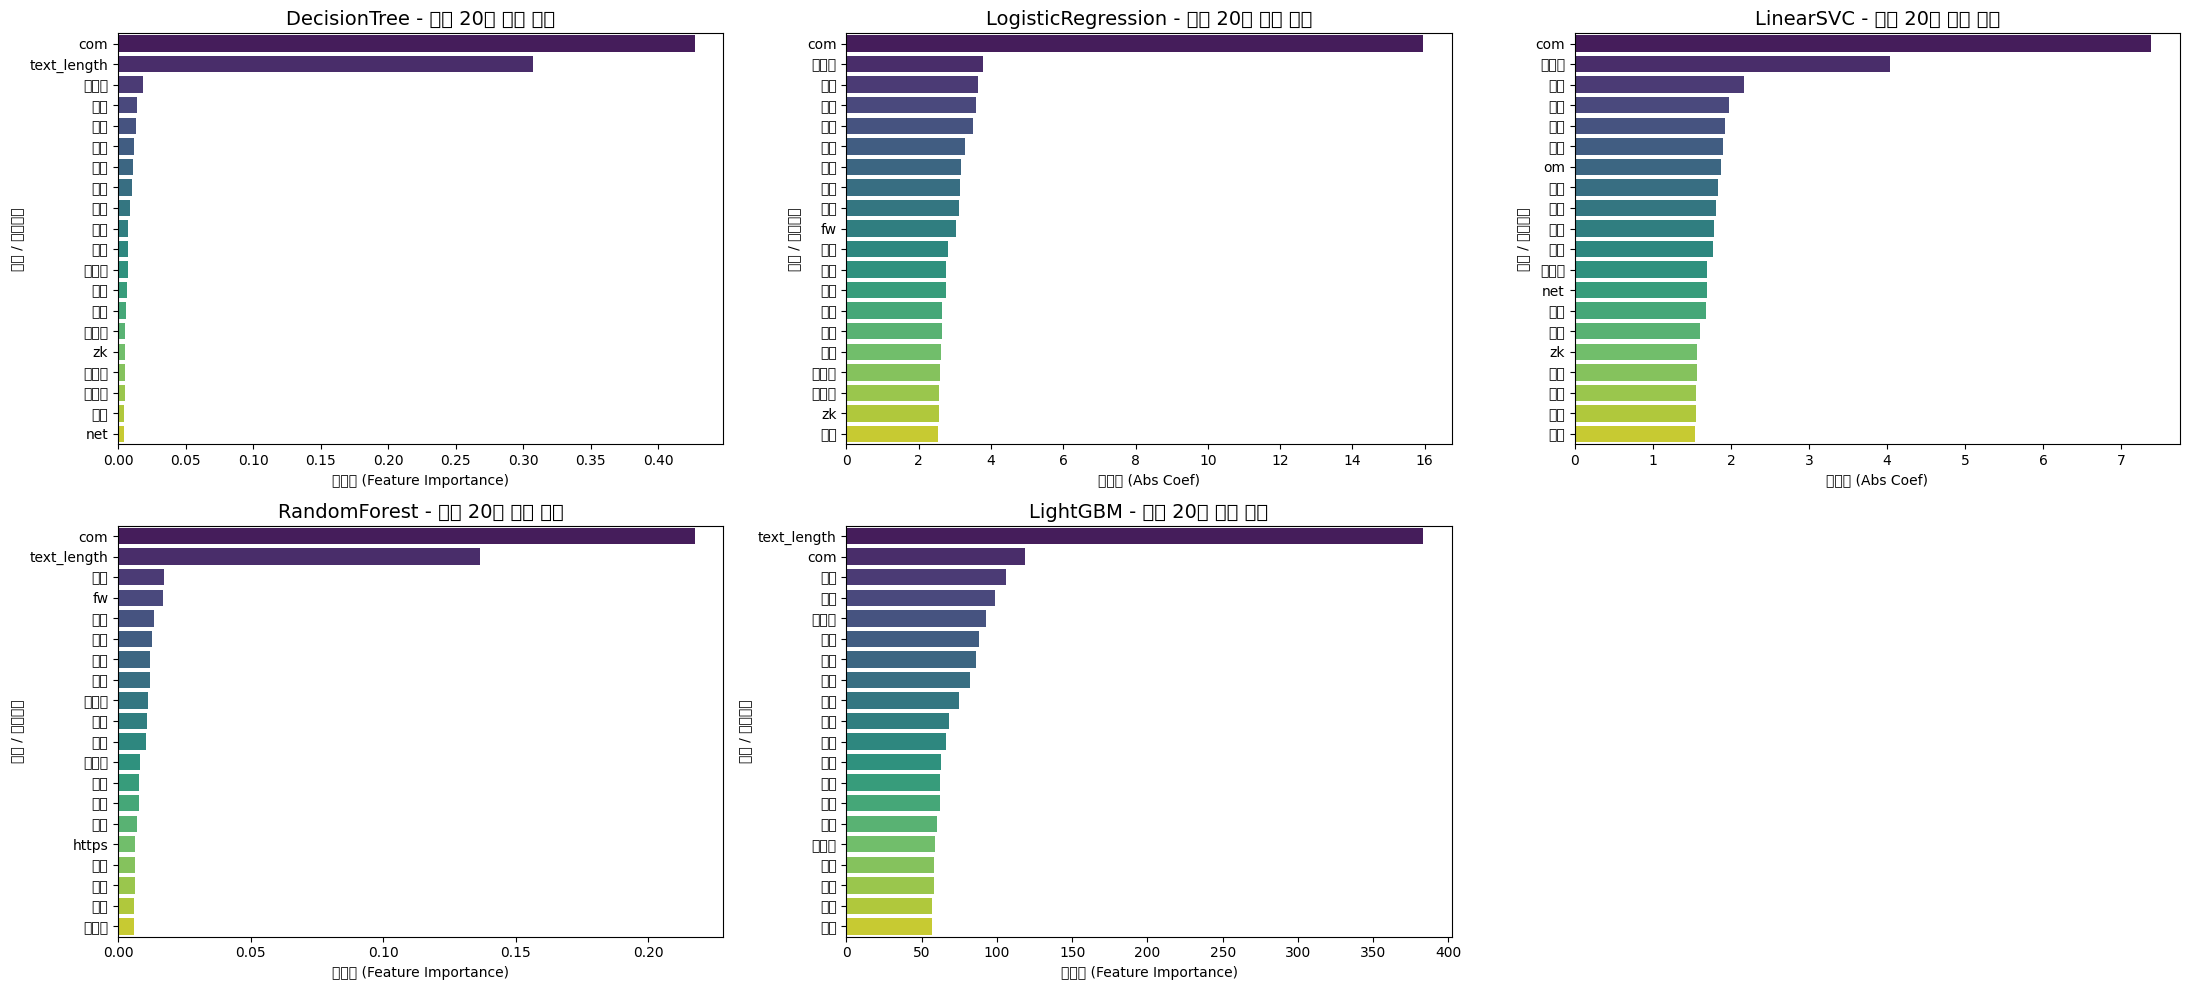

In [25]:
from sklearn.inspection import permutation_importance

# Cell 14에서 실제 모델 입력 X_train을 만들 때 저장한 feature 이름 사용
feature_names = model_feature_names

# 그래프 설정
# RandomForest, LightGBM까지 포함하면 KNN 제외 후에도 모델이 5개일 수 있으므로 2행 3열 사용
fig, axes = plt.subplots(2, 3, figsize=(22, 10))
axes = axes.flatten()
plot_idx = 0

print("▶ Feature Importance 시각화\n")

# 각 모델별 학습 및 중요도 추출
for name, model in models.items():
    model.fit(X_train, y_train)

    # KNN은 피처 중요도를 제공하지 않으므로 건너뜀
    if name == "KNN":
        print(f"  - {name}은 거리 기반 모델이므로 피처 중요도를 직접 추출X \n")
        continue

    # 중요도 값 추출
    if hasattr(model, "feature_importances_"):
        # DecisionTree, RandomForest, LightGBM 등 트리 기반 모델
        importances = model.feature_importances_

    elif hasattr(model, "coef_"):
        # LogisticRegression, LinearSVC 등 선형 모델
        # 계수의 절댓값을 중요도로 사용
        importances = np.abs(model.coef_[0])

    else:
        print(f"  - {name}은 feature importance를 직접 추출할 수 없어 제외합니다.\n")
        continue

    # feature 이름 개수와 importance 개수가 같은지 확인
    if len(feature_names) != len(importances):
        print(f"  - {name}: feature 이름 개수와 중요도 개수가 맞지 않아 제외합니다.")
        print("    feature_names:", len(feature_names))
        print("    importances:", len(importances))
        continue

    # 내림차순 정렬
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    # feature importance 시각화
    sns.barplot(
        x='Importance',
        y='Feature',
        data=feature_importance_df.head(20),
        ax=axes[plot_idx],
        palette=sns.color_palette("viridis", 20)
    )

    axes[plot_idx].set_title(f'{name} - 상위 20개 중요 피처', fontsize=14)

    # x축 라벨을 모델의 특성에 맞게 표기
    if hasattr(model, "feature_importances_"):
        axes[plot_idx].set_xlabel('중요도 (Feature Importance)')
    else:
        axes[plot_idx].set_xlabel('중요도 (Abs Coef)')

    axes[plot_idx].set_ylabel('단어 / 파생변수')

    plot_idx += 1

# 남는 빈 subplot 삭제
for i in range(plot_idx, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

## ELI5

In [26]:
!pip install eli5

import eli5
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from IPython.display import display, HTML

# eli5 표의 글자색을 검정색으로 고정하는 CSS 설정
custom_css = """
<style>
    table.eli5-weights,
    table.eli5-weights th,
    table.eli5-weights td {
        color: black !important;
    }
</style>
"""
display(HTML(custom_css))
#---------------------------------------------------------------

# 상단의 Stratified K-Fold 과정 중 변형되었을 가능성이 존재
# 따라서 학습 데이터 기준으로 행렬을 재구성
# 추후 해당 부분에 대해 보다 효율적인 방식으로 수정하고자 합니다.
tfidf_clean = TfidfVectorizer(max_features=3000)
tfidf_clean.fit(X_train_text)

vocab = tfidf_clean.get_feature_names_out()
feature_names = list(vocab) + ['text_length']

print("▶ LogisticRegression 모델의 단어별 가중치 (Top 20)")
lr_model = models["LogisticRegression"]
display(eli5.show_weights(lr_model, top=20, feature_names=feature_names))


# 테스트 데이터에 대해 로지스틱 회귀로 예측값 계산
y_pred_lr = lr_model.predict(X_test)

# Stratified K-Fold 과정 중 변형되었을 가능성이 존재
# 따라서 이전과 동일하게 error_df 정의
error_df = pd.DataFrame({
    'Actual_Label': y_test.values if hasattr(y_test, 'values') else y_test,
    'Predicted_Label': y_pred_lr,
    'Original_Text': df.iloc[idx_test]["content"].values
})

false_positives = error_df[(error_df['Actual_Label'] == 0) & (error_df['Predicted_Label'] == 1)]

# 특정 오분류 메시지 예측 원인 분석 (eli5)
print("\n▶ False Positive 예측 원인 분석")

if len(false_positives) > 0:
    fp_idx = false_positives.index[0]
    sample_text = false_positives.loc[fp_idx, 'Original_Text']
    print(f"오분류된 텍스트 원문: {sample_text}\n")

    sample_features = X_test.tocsr()[fp_idx]

    display(eli5.show_prediction(
        lr_model,
        sample_features,
        feature_names=feature_names
    ))
else:
    print("현재 정상 문자를 스미싱으로 오분류한(False Positive) 데이터가 없습니다!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 2.2 MB/s eta 0:00:00


▶ LogisticRegression 모델의 단어별 가중치 (Top 20)


Weight?,Feature
+15.948,com
+3.634,신규
+3.574,코드
+3.503,치킨
+3.269,지급
+3.170,커피
+3.134,가입
+3.107,쿠폰
+3.025,fw
+2.804,푸다



▶ False Positive 예측 원인 분석
오분류된 텍스트 원문: 오늘 아침에 우산펴자마자 철사가 뒤집혀 부러졌다 튼튼한 막대우산이였는데ㅡㅡ



In [27]:
# LinearSVC 가중치 색상표 출력

!pip install eli5

import eli5
from IPython.display import display, HTML

# eli5 표 글자색을 검정색으로 고정
custom_css = """
<style>
    table.eli5-weights,
    table.eli5-weights th,
    table.eli5-weights td {
        color: black !important;
    }
</style>
"""
display(HTML(custom_css))

# LinearSVC 모델 학습
target_model = models["LinearSVC"]
target_model.fit(X_train, y_train)

# 실제 모델에 들어간 feature 이름 사용
feature_names = list(model_feature_names)

print("feature 이름 개수:", len(feature_names))
print("X_train feature 개수:", X_train.shape[1])

print("▶ LinearSVC 모델의 단어별 가중치 색상표")

display(
    eli5.show_weights(
        target_model,
        feature_names=feature_names,
        target_names=["정상(0)", "스미싱(1)"],
        top=20
    )
)

feature 이름 개수: 3001
X_train feature 개수: 3001
▶ LinearSVC 모델의 단어별 가중치 색상표


Weight?,Feature
+7.381,com
+1.980,커피
+1.927,지급
+1.905,코드
+1.877,om
+1.829,완료
+1.808,사대
+1.779,치킨
+1.776,푸다
+1.699,편의점


In [28]:
# LinearSVC 기준: 스미싱 방향 / 정상 방향 feature 확인

target_model = models["LinearSVC"]
target_model.fit(X_train, y_train)

feature_names = np.append(tfidf.get_feature_names_out(), "text_length")
coef = target_model.coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coef
})

top_smishing_features = coef_df.sort_values(
    by="Coefficient",
    ascending=False
).head(20)

top_normal_features = coef_df.sort_values(
    by="Coefficient",
    ascending=True
).head(20)

print("▶ 스미싱으로 분류하는 데 강하게 작용한 feature")

display(
    top_smishing_features.style
    .format({"Coefficient": "{:.3f}"})
    .background_gradient(cmap="Greens", subset=["Coefficient"])
)

print("▶ 정상으로 분류하는 데 강하게 작용한 feature")

display(
    top_normal_features.style
    .format({"Coefficient": "{:.3f}"})
    .background_gradient(cmap="Reds_r", subset=["Coefficient"])
)

# combined_coef_df = pd.concat([
#     top_smishing_features,
#     top_normal_features
# ]).reset_index(drop=True)

# display(
#     combined_coef_df.style
#     .format({"Coefficient": "{:.3f}"})
#     .background_gradient(cmap="RdYlGn", subset=["Coefficient"])
# )

▶ 스미싱으로 분류하는 데 강하게 작용한 feature


,Feature,Coefficient
89,com,7.381
2705,커피,1.980
2529,지급,1.927
2712,코드,1.905
345,om,1.877
2066,완료,1.829
1617,사대,1.808
2679,치킨,1.779
2829,푸다,1.776
2811,편의점,1.699


▶ 정상으로 분류하는 데 강하게 작용한 feature


,Feature,Coefficient
1615,사기꾼,-4.037
944,논란,-2.170
2002,여자,-1.367
1263,만들다,-1.293
1886,아니다,-1.263
1972,얼마나,-1.168
924,넘다,-1.124
887,나라,-1.120
1059,대통령,-1.096
2569,진짜,-1.073


In [29]:
# Logistic Regression으로 스미싱 확률 확인 (2등 모델)

# models 딕셔너리에서 LogisticRegression 모델을 가져옴
prob_model = models["LogisticRegression"]

# Logistic Regression 모델을 학습 데이터로 학습
prob_model.fit(X_train, y_train)

# 테스트 데이터에 대해 각 class에 속할 확률을 계산
# predict_proba(X_test)의 결과는 [정상일 확률, 스미싱일 확률] 형태
# [:, 1]은 class 1, 즉 스미싱일 확률만 가져온다는 의미
smishing_prob = prob_model.predict_proba(X_test)[:, 1]

# 스미싱 확률이 0.5 이상이면 스미싱(1), 0.5 미만이면 정상(0)으로 분류
prob_pred = (smishing_prob >= 0.5).astype(int)

# 원문 메시지, 실제 라벨, 예측 라벨, 스미싱 확률을 하나의 DataFrame으로 정리
prob_df = pd.DataFrame({
    "Original_Text": df.iloc[idx_test]["content"].values,
    "True_Label": y_test.values,
    "Predicted_Label": prob_pred,
    "Smishing_Probability": smishing_prob
})

# 스미싱 확률이 높은 메시지부터 확인하기 위해 내림차순 정렬
prob_df = prob_df.sort_values(
    by="Smishing_Probability",
    ascending=False
).reset_index(drop=True)

# 스미싱 확률이 가장 높은 상위 10개 메시지 출력
display(prob_df.head(10))

,Original_Text,True_Label,Predicted_Label,Smishing_Probability
0,(광고)안녕하세요KB저축은행입니다 한 낮의기온이 20도가 훌적 넘어가는 무더운 6...,1,1,1.0
1,(광고)안녕하세요 OK저축은행입니다. 고객이 OK 할 때 까지 고객님을 우선으로 생...,1,1,1.0
2,"(광고) 국민은행 ""당사 (국민)는 여러분을 응원합니다."" 이용해 주신 고객님에...",1,1,1.0
3,"(광고) ""온국민의 〔KB금융〕이 새시대를 함께할 금융 파트너가 되겠습니다."" 나...",1,1,1.0
4,"(광고) ""당사〈shin han〉는 여러분이 힘들때 마다 곁에 있습니다. 고객님 ...",1,1,1.0
5,"(광고) 『KB.금융』과 함께하는 앞서가는 미래경제"" 복잡한 절차를 정부의 ...",1,1,1.0
6,(광고)페퍼저축은행테 마 상 품2020.03.23일 기준신용등급관계없이이용가능연3....,1,1,1.0
7,(광고)페퍼축은행페 퍼 만의특별한 테마상품신 용 등 급 관계 없이 이용가능연3.20...,1,1,1.0
8,"우리은행\n\n[Web발신]\n(광고)\n\n"" 고객과 함께 한다면 저희 '우리은행...",1,1,1.0
9,(제목 없음)\n\n[Web 발신]\n(공고)BK무역\n신차수출 아르바이트\n수출지...,1,1,1.0


In [30]:
from sklearn.calibration import CalibratedClassifierCV

# LinearSVC으로 스미싱 확률 확인 (1등 모델)

# LinearSVC는 기본적으로 predict_proba()를 제공하지 않음
# 따라서 CalibratedClassifierCV를 사용해 LinearSVC의 decision score를 확률값으로 보정함
calibrated_svc = CalibratedClassifierCV(
    LinearSVC(class_weight="balanced", random_state=42),
    cv=5
)

# 보정된 LinearSVC 모델을 학습 데이터에 학습시킴
calibrated_svc.fit(X_train, y_train)

# 테스트 데이터에 대해 스미싱일 확률을 계산
# predict_proba(X_test)의 결과는 [정상 확률, 스미싱 확률] 형태
# [:, 1]은 class 1, 즉 스미싱일 확률만 가져온다는 의미
svc_smishing_prob = calibrated_svc.predict_proba(X_test)[:, 1]

# 확률이 0.5 이상이면 스미싱(1), 아니면 정상(0)으로 분류
svc_pred = (svc_smishing_prob >= 0.5).astype(int)

# 원문, 실제 라벨, 예측 라벨, 스미싱 확률을 하나의 표로 정리
svc_prob_df = pd.DataFrame({
    "Original_Text": df.iloc[idx_test]["content"].values,
    "True_Label": y_test.values,
    "Predicted_Label": svc_pred,
    "Smishing_Probability": svc_smishing_prob
})

# 스미싱 확률이 높은 순서대로 정렬
svc_prob_df = svc_prob_df.sort_values(
    by="Smishing_Probability",
    ascending=False
).reset_index(drop=True)

# 상위 10개 출력
# 모델이 상위 문자들을 강하게 스미싱으로 예측하는지 확인하기 위해 소수점 8자리까지의 확률 출력 (상위권은 모두 1로 예측)
display(svc_prob_df.head(20).style.format({"Smishing_Probability": "{:.8f}"}))


,Original_Text,True_Label,Predicted_Label,Smishing_Probability
0,"(광고) 『KB.금융』과 함께하는 앞서가는 미래경제"" 복잡한 절차를 정부의 제도개편을 통해 간소화함으로 빠른 진행이 가능한 대환대출이며 추가자금 승인도 가능한 상품입니다. 【상품 요약】 -한도- *대환 : ~ 1억원 *추가 : 5백만원 ~ 2천 5백만원 *금 리 :연 2.35% ~ 6.65% *대출기간 : 2년 ~ 8년 원(리)금 균등상환, 만기일시 -대상자- *만20세이상 *3대보험 가입여부 X(휴직이나 현금소득자) *당사 심사기준에 적합하신 고객 **최근 타 금융사에서 부결 대상자도 신청 가능 ※신용불량이시거나 이미 연체관리가 안되신 고객님은 진행이 어려우십니다. 『신청 안내』 ☏02-6239-0326 접수상담시간 :평일 09:20 ~ 18:00 ARS접수로 신청이 가능하며 음성안내에 따라 연락처를 남기시면 상담사와 연결되십니다. ※본 상품은 승인 이전 모든과정에서의 조회는 신용등급에 반영되지 않습니다. 무료거부0808887886",1,1,1.00000000
1,"(광고)안녕하세요KB저축은행입니다 한 낮의기온이 20도가 훌적 넘어가는 무더운 6월 입니다 야회 활동시 건강에 유의하시길 바라며 이번 정부에서 지원하고있는 생할안전자금 안내차 연락드립니다 신 청 대 상* - 만20세 이상 - 기존 거래중이시거나 신규 대상자 - 현재 소득증빙이 어려우시거나 조금미달이신분 - 높은 기대출로 고민중이신분 - 거래 내역이 없어도 신규로 진행가능 *신 청 한 도* - 기간:기본 2~7년(최장 10년까지연장가능) - 상환방식:만기일시.원리금균등분활방식 또는 자율상환방식 - 금리:연2.2%~부터 평점에따라 차등 적용 - 한도:800만원~1억7000만원 [신청기간] 2020년 6월 26일마감 ※ 접수자가 많으니 빠른신청 바랍니다 [신청방법] - 02-2297-0385 - 통화후,1번을 눌러주시면 신청 완료 지점을 방문예정이신분은 임시 영업중단 지점을 필히 확인하시고 마스크를 꼭 착용해 주시기 바랍니다 ※ 단순 가조회로 인하여 고객님의 신용도는 문제가없음을 알려드립니다 무료수신거부 080-870-0898",1,1,1.00000000
2,"(광고) ""당사〈shin han〉는 여러분이 힘들때 마다 곁에 있습니다. 고객님 힘내세요"" 거리두기 실행으로 인한 경제적 압박으로 생계활동에 어려움이 많은 시점에 정부의 지원을 통하여 쉽게 신청이 가능한 대출상품 안내 드립니다. [상품 개요] 노동자와 자영업자에게 전환대출과 더불어 생계자금까지 지원된 상품 *한도 : 최대1억원 *금리 : 연 2.63% ~ 6.32% *기간 : 2년 ~ 10년 *자율상환(원금 만기 일시납) 【자격 대상】 -만 19세 이상 국내 거주자 -직업이나 소득에 관계 무관 -과다 연체나 면책이력 없는 고객 -개인 신용으로 신청 가능 -기대출 보유대상자 -자사 기존고객 우대 및 신규고객 [접수 신청] ☎02-6306-1158 평일 09:00 ~ 18:00 마감: 사전예산 모두 소진시 자동 종료됩니다. ※고객의 편리를 위해 내선 연결을 최소화한 1:1방식으로 상담진행 됩니다. 무료거부0808552877",1,1,1.00000000
3,"(광고) 국민은행 ""당사 (국민)는 여러분을 응원합니다."" 이용해 주신 고객님에게 감사인사 드립니다. 본상품은 거리두기 강화로 인해 또 한번 경제 활동관련 생계유지 가 어려운 고객 대상에게 정부지원 예산을 통해 손쉽게 접할 수 있는 통합대출 상품 안내 드립니다. 【상품 설명】 한시적으로 대출규제를 완화 하여 생계자금과 가계대출 전환까지 운용이 가능한 상품입니다. -한도 : 최대 2억원 -금리 : 연 2.0% ~ 5.3% -기간 : 5년 ~ 10년 *원(리)금 균등상환 ※중도 상환 수수료 없음 【자격 조건】 *만 19세 이상 내국인 *회생, 파산, 면책 등 신청 사실이 없는 고객 *타 금융권 최근 부결 *소득대비 과다 기대출 보유자 *소득과 직업에 관계 없이 신청 ※단,개인회생 및 파산으로 면책 이력이 있거나 신불자는 제외 대상입니다. 〈상담 신청〉 ☎02-6081-2039 상담시간:09:00 ~ 18:00 ※개인정보보호법에 의해 신용조회 기록이 전혀 남지 않아 부담 없이 상담가능합니다. 무료거부0808552877",1,1,1.00000000
4,"(광고)안녕하세요 OK저축은행입니다. 고객이 OK 할 때 까지 고객님을 우선으로 생각하고 행동하겠습니다. 2020년 10월 20일까지 한국자산관리공사에서 10% 이상의 높은 이율상품을 자사상품으로 전환할 수 있고, 최대 9000만원까지 가능한 상품을 안내 드립니다. [대상] - 만 20세 이상 - 연체 및 신용상 문제가 없는 모든 고객 - 사업자는 우대금리적용 - 무직/무소득자/주부 가능 [내용] - 한도 최대 9000만 - 월 5.2% ~ 8.7% - 원리금균등상환/만기일시상환 - 1년이내약정/ 최장 5년까지 기간연장가능 [신청] - 본 문자 수신번호로 전화 - 상담원 연결 또는 1번 눌러 상담접수 - 상담시간 오전 9:00 ~ 오후 18:00 # 본 상품은 10월 20일까지 한시적으로 진행되는 상품입니다. # 신청한 개인정보는 암호화되어 안전하게 처리되니 안심하시고 문의주세요. # 본 광고는 개인정보보호법에 의거하여 수신거부등록이 가능합니다. 무료수신거부 0802761202",1,1,1.00000000
5,"(광고)페퍼저축은행테 마 상 품2020.03.23일 기준신용등급관계없이이용가능연3.20%~8%천만원~이억 신청가능합니다임대차 계약서상 임차보증금의팔프로 범위내에서 최대 2억실제 상 품 금 액은 연소득, 부채금액 등 개인별 신용평가에 의해 결정됩니다(상 품/신 청)페퍼복잡한 우대금리·중도상환수수료 NO(신청자격조건)1.만21세~65세 이용가능2.최근부결자 다중 채무자 이용가능신청기간)종료.2020년05월01일까지(ARS/신청방법) 1.안내멘트 도중 1번. 2.안내멘트에 따라 연락받으실 전화번호 입력후 *표2.신청금액 입력후 *표 상담접수 완료(신청접수)고객상담센터 02-820-5728상담시간 AM 9:00~PM 6:00ARS/상담/(23시간265일)콜센터접수 23시간 연중무휴 접수[PEPEER 그 룹 네트워크]무료거부0808555562",1,1,1.00000000
6,"(광고)페퍼축은행페 퍼 만의특별한 테마상품신 용 등 급 관계 없이 이용가능연3.20%~8%~9% 1,000만원~1억5천만원 신청가능합니다임대차 계약서상 임차보증금의 80% 범위내에서 최대 일억까지 다만, 실제 대출금액은 연소득, 부채금액 등 개인별 신용평가에 의해 결정됩니다.페 퍼복잡한 우대금리·중도상환수수료 NO신청자격조건만21세~65세 이용가능최근부결자 다중채무자 이용가능신청기간시작.2020년3월6일종료.2020년3월17일ARS/신청방법 1.안내멘트 도중 1번. 2.안내멘트에 따라 연락받으실 전화번호 입력후 *표2.신청금액 입력후 *표 상담접수 완료신청접수고객상담센터 02-820-8606상담시간 AM 9:00~PM 6:00ARS/상담/(23시간265일)콜센터접수 23시간 연중무휴 접수무료거부0808555562",1,1,1.00000000
7,"(광고) ""온국민의 〔KB금융〕이 새시대를 함께할 금융 파트너가 되겠습니다."" 나날이 어두워져 가는 가계경제에 정부의 따뜻한 추가적 예산지원으로 자금회전이 어려운 자영업자나 생활자금으로 고민하시는 고객님께 필요한 대출상품을 안내드립니다. ｛상품내용｝ * 한 도 : 2천만원 ~ 최대 7천만원 *대출금리 : 연 2.88% ~ 7.63% *대출기간 : 2년 ~ 5년 (최대 120개월까지 연장가능) *상환방법 :원금자유상환 및 원(리)금 균등상환 ｛ 대 상 ｝ -만20세이상 누구나 -경영에 어려움을 겪고 계신 영세 자영업자 -소득적거나 신용등급이 낮아도 가능 -3대보험 가입여부와 직업군 무관하여 학생, 주부, 프래린서도 가능 ※신용불량자이시거나 과연체자는 진행이 어렵습니다. [신청 접수] ☎1577-5281 상담시간: 09:20 ~ 18:00 ※추가예산안에 한시적인 상품이므로 예산 소진시 조기 마감 될수 있습니다. 무료거부 0808817302",1,1,1.00000000
8,"우리은행

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47700 (\N{HANGUL SYLLABLE ME}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/loca

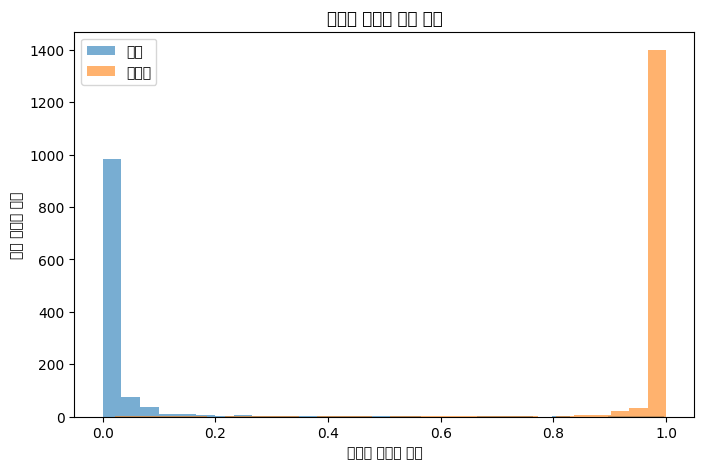

In [31]:
# LinearSVC 모델 라벨별 확률 분포 그래프
plt.figure(figsize=(8, 5))

plt.hist(
    svc_prob_df[svc_prob_df["True_Label"] == 0]["Smishing_Probability"],
    bins=30,
    alpha=0.6,
    label="정상"
)

plt.hist(
    svc_prob_df[svc_prob_df["True_Label"] == 1]["Smishing_Probability"],
    bins=30,
    alpha=0.6,
    label="스미싱"
)

plt.xlabel("예측된 스미싱 확률")
plt.ylabel("문자 메시지 개수")
plt.title("예측된 스미싱 확률 분포")
plt.legend()
plt.show()

In [32]:
# 확률 구간별 개수
svc_prob_df["Probability_Bin"] = pd.cut(
    svc_prob_df["Smishing_Probability"],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    include_lowest=True
)

prob_bin_table = svc_prob_df.groupby("Probability_Bin").size().reset_index(name="Count")

display(prob_bin_table)

/tmp/ipykernel_4635/2423116348.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prob_bin_table = svc_prob_df.groupby("Probability_Bin").size().reset_index(name="Count")


,Probability_Bin,Count
0,"(-0.001, 0.2]",1129
1,"(0.2, 0.4]",27
2,"(0.4, 0.6]",16
3,"(0.6, 0.8]",15
4,"(0.8, 1.0]",1474


In [33]:
# 애매한 문자 확인
# 확률이 0.4~0.6인 문자
uncertain_cases = svc_prob_df[
    (svc_prob_df["Smishing_Probability"] >= 0.4) &
    (svc_prob_df["Smishing_Probability"] <= 0.6)
]

print("애매한 예측 개수:", len(uncertain_cases))

display(
    uncertain_cases.sort_values("Smishing_Probability").head(20)
)

애매한 예측 개수: 16


,Original_Text,True_Label,Predicted_Label,Smishing_Probability,Probability_Bin
1504,조센진들의 문제점은 역사를 보나 국력을 보나 리더쉽을 보나 관광을 보나 제일 열등하...,0,0,0.401094,"(0.4, 0.6]"
1503,*+* *+* **+* **+***+** **+** ***+**eⓚ-gⓗ.comKB...,1,0,0.441005,"(0.4, 0.6]"
1502,이사비지원 *오시면 서 울*８pph.com,1,0,0.446353,"(0.4, 0.6]"
1501,닭년이 얼마나 뻔뻔하냐면 국민 담화에서 검찰 조사에 성실히 임하겠다 해놓고 검찰 조...,0,0,0.450079,"(0.4, 0.6]"
1500,㈜ ⓓⓡb-ⓢp.com옛.백/도 **% 두개다.돌/발**- * *시 까지락 디알일...,1,0,0.471130,"(0.4, 0.6]"
1499,시크릿가든 정주행할까 태양의후예 정주행할까 고민하고 있겠죠?,0,0,0.484206,"(0.4, 0.6]"
1498,새로운 제국주의 시작인가,0,0,0.487277,"(0.4, 0.6]"
1497,놀> Cㅈi 노이> 첫**터> 매**무> ***wwe.com사> 코 ksks,1,1,0.516994,"(0.4, 0.6]"
1496,엄마~내꺼 폰 액정이 깨져서\nA/S맡겻어ㅠ 부탁할거 있어\n여기로 문ㅈㅏ줘,1,1,0.527250,"(0.4, 0.6]"
1495,헬조센징은 따로 존재한거였다 딱 지금 정치인들이 원하는 대로 움직이는 정치깡패새끼들...,0,1,0.528858,"(0.4, 0.6]"


In [34]:
print("최소 확률:", svc_smishing_prob.min())
print("최대 확률:", svc_smishing_prob.max())
print("평균 확률:", svc_smishing_prob.mean())

# 모델이 만든 서로 다른 확률값이 몇 개 있는지 확인
print("고유 확률 개수:", len(np.unique(svc_smishing_prob)))

최소 확률: 4.428545757564764e-06
최대 확률: 1.0
평균 확률: 0.5666049942159322
고유 확률 개수: 2550


## SHAP

In [35]:
!pip install shap
import shap
import numpy as np

# 이미 학습된 LinearSVC 가져오기 (models 딕셔너리의 평가 루프에서 fit됨)
svc = models["LinearSVC"]

# 0) feature 이름: TF-IDF 단어 3000개 + 'text_length' (RF와 동일)
feature_names_svc = np.append(tfidf.get_feature_names_out(), 'text_length')

# 1) COO → CSR 변환 (행 인덱싱 위해). LinearExplainer는 sparse 입력 OK
X_train_csr = X_train.tocsr()
X_test_csr  = X_test.tocsr()

# 2) 테스트셋에서 300건 샘플링
n_sample = 300
rng = np.random.RandomState(42)
idx = rng.choice(X_test_csr.shape[0], size=min(n_sample, X_test_csr.shape[0]), replace=False)
X_shap_svc = X_test_csr[idx]              # sparse 그대로 SHAP 계산 가능
X_shap_dense = X_shap_svc.toarray()       # 시각화(점 색칠)용 dense 버전

# 3) LinearExplainer (선형 모델 전용). background로 X_train의 분포(평균) 사용
explainer_svc = shap.LinearExplainer(svc, X_train_csr)
shap_values_svc = explainer_svc.shap_values(X_shap_svc)   # shape: (n, n_features) — 단일 출력

base_val = explainer_svc.expected_value
base_val = base_val[0] if hasattr(base_val, '__len__') else base_val

/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 44553 (\N{HANGUL SYLLABLE GEUB}) 

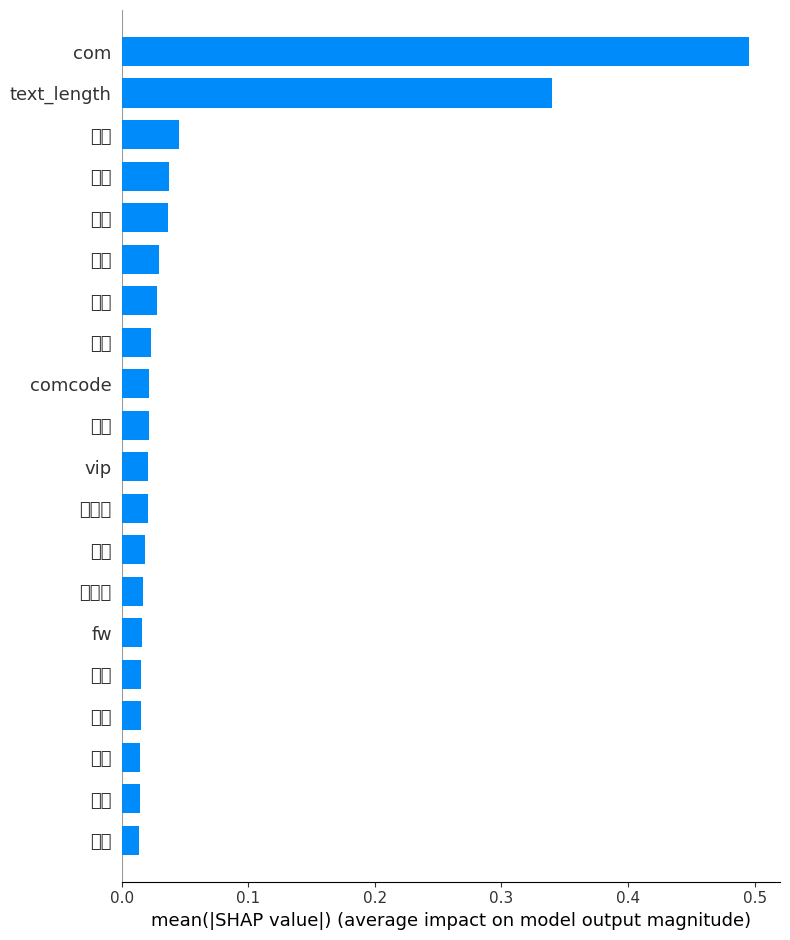

In [36]:
# (a) Bar: 전역 중요도
shap.summary_plot(shap_values_svc, X_shap_dense, feature_names=feature_names_svc, plot_type="bar")

/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 44553 (\N{HANGUL SYLLABLE GEUB}) 

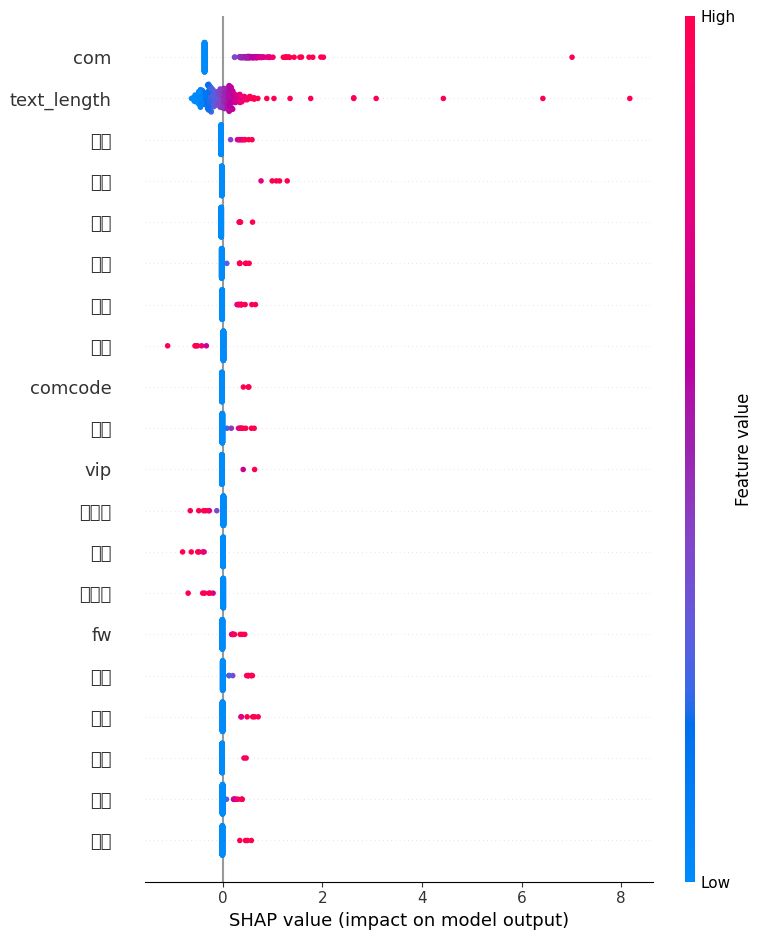

In [37]:
# (b) Dot: 영향 방향 (빨강=단어 TF-IDF 큼, 파랑=작음)
shap.summary_plot(shap_values_svc, X_shap_dense, feature_names=feature_names_svc, plot_type="dot")

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53076 (\N{HANGUL SYLLABLE KO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44508 (\N{HANGUL SYLLABLE GYU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

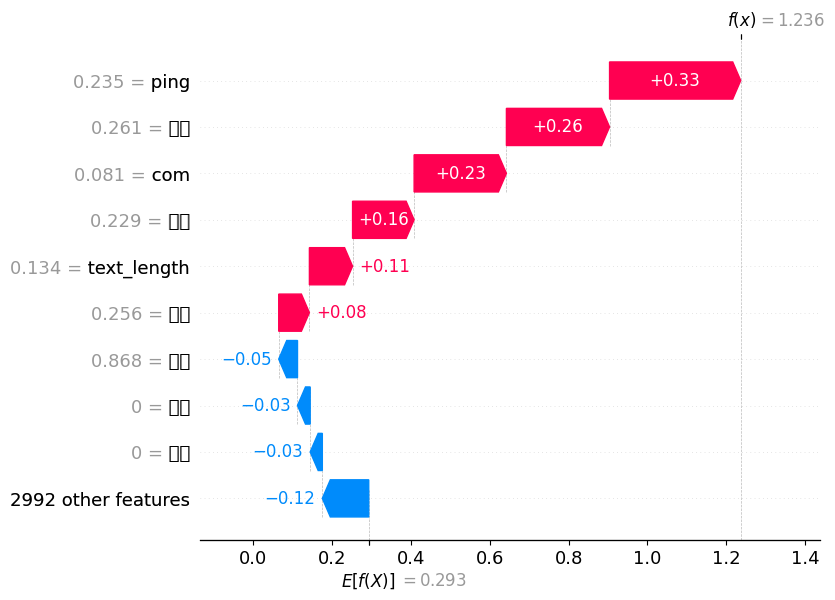

In [38]:
# (c) Waterfall: 개별 문자 1건 분해
i = 0
explanation_svc = shap.Explanation(
    values=shap_values_svc[i],
    base_values=base_val,
    data=X_shap_dense[i],
    feature_names=feature_names_svc,
)
shap.plots.waterfall(explanation_svc)

## Error Analysis

In [39]:
import pandas as pd
from sklearn.model_selection import train_test_split

print("[Error Analysis: 오분류 데이터 분석]\n")

# 원본 텍스트 데이터를 훈련/테스트 셋과 동일하게 분할하여 텍스트 복구
_, text_test = train_test_split(df['content'], test_size=0.2, random_state=42, stratify=df['class'])

# 로지스틱 회귀 모델 예측 (다른 모델 결과를 보고 싶다면 models 뒤 괄호 안의 영어만 바꿔주면 됨)
target_model = models["LogisticRegression"]
y_pred = target_model.predict(X_test)

# 실제 정답, 예측 정답, 원본 텍스트를 하나의 데이터프레임으로 결합
error_df = pd.DataFrame({
    'Actual_Label': y_test,
    'Predicted_Label': y_pred,
    'Original_Text': text_test.values
})

# # Cell 14에서 저장한 idx_test를 사용해 실제 test set의 원문을 복구
# text_test = df.iloc[idx_test]["content"]

# # 로지스틱 회귀 모델 예측
# target_model = models["LogisticRegression"]
# target_model.fit(X_train, y_train)
# y_pred = target_model.predict(X_test)

# error_df = pd.DataFrame({
#     "Actual_Label": y_test.values,
#     "Predicted_Label": y_pred,
#     "Original_Text": text_test.values
# })

# 데이터에 존재하는 실제 고유 라벨 값을 찾아내기
actual_labels = sorted(error_df['Actual_Label'].unique())
print(f"▶ 데이터셋에 존재하는 실제 라벨 값: {actual_labels}")

normal_class = actual_labels[0]
smishing_class = actual_labels[1]
print(f"  - 자동 설정됨: 정상 라벨({normal_class}), 스미싱 라벨({smishing_class})\n")

# 모델이 틀린 데이터만 필터링
wrong_predictions = error_df[error_df['Actual_Label'] != error_df['Predicted_Label']]

# False Positive (정상 -> 스미싱으로 오해)
false_positives = wrong_predictions[
    (wrong_predictions['Actual_Label'] == normal_class) &
    (wrong_predictions['Predicted_Label'] == smishing_class)
]

# False Negative (스미싱 -> 정상으로 오해)
false_negatives = wrong_predictions[
    (wrong_predictions['Actual_Label'] == smishing_class) &
    (wrong_predictions['Predicted_Label'] == normal_class)
]

print(f"▶ 총 테스트 데이터 {len(y_test)}개 중 오분류된 데이터: {len(wrong_predictions)}개")
print(f"  - 정상 -> 스미싱으로 오해 (False Positive): {len(false_positives)}개")
print(f"  - 스미싱 -> 정상으로 오해 (False Negative): {len(false_negatives)}개\n")

# Data Exploration 단계에서 스미싱 문자에 가장 많이 나온 상위 4개 단어가 실제로 잘 분류되었는지 검증
keywords = ['신청', '신규', '상품', '번호']

print("[검증: 정상 문자를 스미싱으로 오해한 경우]")
if len(false_positives) > 0:
    for keyword in keywords:
        count = false_positives['Original_Text'].fillna('').str.contains(keyword).sum()
        print(f"오분류된 정상 문자 중 '{keyword}' 단어 포함 건수: {count}건 ({(count/len(false_positives))*100:.1f}%)")

    print("\n[False Positive 실제 메시지 내용 확인 (상위 10개)]")
    pd.set_option('display.max_colwidth', None)
    display(false_positives[['Original_Text']].head(10))
    pd.reset_option('display.max_colwidth')
else:
    print("정상 문자를 스미싱으로 오분류한 데이터가 없습니다!")

if len(false_negatives) > 0:
    print("\n[False Negative 실제 메시지 내용 확인 (상위 10개)]")
    pd.set_option('display.max_colwidth', None)
    display(false_negatives[['Original_Text']].head(10))
    pd.reset_option('display.max_colwidth')

[Error Analysis: 오분류 데이터 분석]

▶ 데이터셋에 존재하는 실제 라벨 값: [np.int64(0), np.int64(1)]
  - 자동 설정됨: 정상 라벨(0), 스미싱 라벨(1)

▶ 총 테스트 데이터 2661개 중 오분류된 데이터: 63개
  - 정상 -> 스미싱으로 오해 (False Positive): 23개
  - 스미싱 -> 정상으로 오해 (False Negative): 40개

[검증: 정상 문자를 스미싱으로 오해한 경우]
오분류된 정상 문자 중 '신청' 단어 포함 건수: 0건 (0.0%)
오분류된 정상 문자 중 '신규' 단어 포함 건수: 0건 (0.0%)
오분류된 정상 문자 중 '상품' 단어 포함 건수: 0건 (0.0%)
오분류된 정상 문자 중 '번호' 단어 포함 건수: 0건 (0.0%)

[False Positive 실제 메시지 내용 확인 (상위 10개)]


,Original_Text
4375,오늘 아침에 우산펴자마자 철사가 뒤집혀 부러졌다 튼튼한 막대우산이였는데ㅡㅡ
3723,영국이나 호주처럼 제정증명 확인하고 떼줘라...
1978,어느 협회는 회장까지 출동해서 뒷바라지하고 이것들은 말단직원 보내는 돈도 아까워서 안보내고...
3908,2년 뒤엔 야구 안할거냐... 산도발 다시 2루 무혈입성이네. 투수 유망주들 다 팔아제꼈고.... 몬카다도 팔았고 기대할 유망주가....ㅠ
5822,"닭: 절대 사익을 위해 부정을 저지르지 않았습니다. 다만, 친박계 관련 측근들이 세력 확산 및 그들의 이익을 위해 보스로서 책임을 다한것 일뿐"
467,탑 kt우세. 정글 미드 봇 스크우세
4739,내가 맹세하는데 한달 100만원씩 육아보조금 줘도 맡길 년들은 어린이집에 맡긴다. 한마디로 지 편할라고 맡기는 거다.
2727,닭년이 얼마나 뻔뻔하냐면 국민 담화에서 검찰 조사에 성실히 임하겠다 해놓고 검찰 조사 거부함. 그래놓고 헌재에 보낸 답변서에는 검찰 조사를 받지못해 항변도 못했다고 함. 양심이 아예 없음
2811,"가격 정한 심리를 알거같다. 노트7은 곧 정상화기기풀려도 난리한바탕 친뒤라 그래도 뭔가 꺼리는계층 이 있을거고, 아이폰은 2차 판매국에도 못들고 공급달릴정도니 한국에 정식출시는 한 11월가야 될듯한데 한두달 동안에 90만원에 팔고 아이폰 출시되면 한 20만원 후려칠듯"
5948,한화 사훈이 의리 라는거 모르냐? 김성근 데려와 달라고 1인 시위까지하던 한화 팬들을 보고 감동해서 회장님이 직접 모셔온 감독을 이제와서 경질 시킬꺼 같아?



[False Negative 실제 메시지 내용 확인 (상위 10개)]


,Original_Text
10508,**+* **+* **+****+** ***+***년무사고 보증업체E벤 놀거리 많아요KEY▷**ⓥⓣ-cr.com
12436,이사비지원 *오시면 서 울*８pph.com
11512,놀> Cㅈi 노이> 첫**터> 매**무> ***wwe.com사> 코 ksks
339,엄마 나 폰박살났어 ㅠ 0105552???7 이번호로 카톡추가하고 톡줘
342,엄마 나 폰 망가져서 수리센터 맡기고 컴으로 하고잇어 엄마지금바뻐?
12524,필드원'돌뱔일야**%**~**시fo-ⓐz.com
7963,제?*+* *+* **╉* **+*재?**╉** **+** ***+**업?국야일야ㄱ슴? 코두TSkd-ⓜk.com
4,엄마~ 바빠?\n엄마 나 급한 일이 좀 생겨서…\n지금 98만원만 입금해 줄 수 있어?+C6
8860,"륄,릴 adressTⓞ-Kⓣ.comLiL 예뷔도맨까*: LiL****"
11773,*-만 받고 +총 ▶* O◀ % 또받자바▽ 카▶라⑨**ⓜv.com


In [40]:
import pandas as pd
from sklearn.model_selection import train_test_split

print("[Error Analysis: LinearSVC 오분류 데이터 분석]\n")

# # 원본 텍스트 데이터를 훈련/테스트 셋과 동일하게 분할하여 텍스트 복구
# _, text_test = train_test_split(df['content'], test_size=0.2, random_state=42, stratify=df['class'])

# # 로지스틱 회귀 모델 예측 (다른 모델 결과를 보고 싶다면 models 뒤 괄호 안의 영어만 바꿔주면 됨)
# target_model = models["LogisticRegression"]
# y_pred = target_model.predict(X_test)

# # 실제 정답, 예측 정답, 원본 텍스트를 하나의 데이터프레임으로 결합
# error_df = pd.DataFrame({
#     'Actual_Label': y_test,
#     'Predicted_Label': y_pred,
#     'Original_Text': text_test.values
# })

# Cell 14에서 저장한 idx_test를 사용해 실제 test set의 원문을 복구
text_test = df.iloc[idx_test]["content"]

# 로지스틱 회귀 모델 예측
target_model = models["LinearSVC"]
target_model.fit(X_train, y_train)
y_pred = target_model.predict(X_test)

error_df = pd.DataFrame({
    "Actual_Label": y_test.values,
    "Predicted_Label": y_pred,
    "Original_Text": text_test.values
})

# 데이터에 존재하는 실제 고유 라벨 값을 찾아내기
actual_labels = sorted(error_df['Actual_Label'].unique())
print(f"▶ 데이터셋에 존재하는 실제 라벨 값: {actual_labels}")

normal_class = actual_labels[0]
smishing_class = actual_labels[1]
print(f"  - 자동 설정됨: 정상 라벨({normal_class}), 스미싱 라벨({smishing_class})\n")

# 모델이 틀린 데이터만 필터링
wrong_predictions = error_df[error_df['Actual_Label'] != error_df['Predicted_Label']]

# False Positive (정상 -> 스미싱으로 오해)
false_positives = wrong_predictions[
    (wrong_predictions['Actual_Label'] == normal_class) &
    (wrong_predictions['Predicted_Label'] == smishing_class)
]

# False Negative (스미싱 -> 정상으로 오해)
false_negatives = wrong_predictions[
    (wrong_predictions['Actual_Label'] == smishing_class) &
    (wrong_predictions['Predicted_Label'] == normal_class)
]

print(f"▶ 총 테스트 데이터 {len(y_test)}개 중 오분류된 데이터: {len(wrong_predictions)}개")
print(f"  - 정상 -> 스미싱으로 오해 (False Positive): {len(false_positives)}개")
print(f"  - 스미싱 -> 정상으로 오해 (False Negative): {len(false_negatives)}개\n")

# Data Exploration 단계에서 스미싱 문자에 가장 많이 나온 상위 4개 단어가 실제로 잘 분류되었는지 검증
keywords = ['신청', '신규', '상품', '번호']

print("[검증: 정상 문자를 스미싱으로 오해한 경우]")
if len(false_positives) > 0:
    for keyword in keywords:
        count = false_positives['Original_Text'].fillna('').str.contains(keyword).sum()
        print(f"오분류된 정상 문자 중 '{keyword}' 단어 포함 건수: {count}건 ({(count/len(false_positives))*100:.1f}%)")

    print("\n[False Positive 실제 메시지 내용 확인 (상위 10개)]")
    pd.set_option('display.max_colwidth', None)
    display(false_positives[['Original_Text']].head(10))
    pd.reset_option('display.max_colwidth')
else:
    print("정상 문자를 스미싱으로 오분류한 데이터가 없습니다!")

if len(false_negatives) > 0:
    print("\n[False Negative 실제 메시지 내용 확인 (상위 10개)]")
    pd.set_option('display.max_colwidth', None)
    display(false_negatives[['Original_Text']].head(10))
    pd.reset_option('display.max_colwidth')

[Error Analysis: LinearSVC 오분류 데이터 분석]

▶ 데이터셋에 존재하는 실제 라벨 값: [np.int64(0), np.int64(1)]
  - 자동 설정됨: 정상 라벨(0), 스미싱 라벨(1)

▶ 총 테스트 데이터 2661개 중 오분류된 데이터: 34개
  - 정상 -> 스미싱으로 오해 (False Positive): 10개
  - 스미싱 -> 정상으로 오해 (False Negative): 24개

[검증: 정상 문자를 스미싱으로 오해한 경우]
오분류된 정상 문자 중 '신청' 단어 포함 건수: 0건 (0.0%)
오분류된 정상 문자 중 '신규' 단어 포함 건수: 0건 (0.0%)
오분류된 정상 문자 중 '상품' 단어 포함 건수: 0건 (0.0%)
오분류된 정상 문자 중 '번호' 단어 포함 건수: 0건 (0.0%)

[False Positive 실제 메시지 내용 확인 (상위 10개)]


,Original_Text
352,오늘로써 18주 되는 예비맘인데요~~
400,영국이나 호주처럼 제정증명 확인하고 떼줘라...
573,탑 kt우세. 정글 미드 봇 스크우세
633,내가 맹세하는데 한달 100만원씩 육아보조금 줘도 맡길 년들은 어린이집에 맡긴다. 한마디로 지 편할라고 맡기는 거다.
709,"가격 정한 심리를 알거같다. 노트7은 곧 정상화기기풀려도 난리한바탕 친뒤라 그래도 뭔가 꺼리는계층 이 있을거고, 아이폰은 2차 판매국에도 못들고 공급달릴정도니 한국에 정식출시는 한 11월가야 될듯한데 한두달 동안에 90만원에 팔고 아이폰 출시되면 한 20만원 후려칠듯"
1506,근데 졌다고 남자친구한테 말하니까 놀리는 말투로 졌데요~~ 졌데요~~
2274,소나무도 막 베더니 사진충들
2395,비밀비밀 아 이 죄인들 예전 공화국때처럼 자백 받아?? 그리고 비밀로 해 난 몰라
2543,헬조센징은 따로 존재한거였다 딱 지금 정치인들이 원하는 대로 움직이는 정치깡패새끼들은 지들이 그렇게 원하는 독재국가로 보내버려야된다
2656,메갈 회원끼린 하이!



[False Negative 실제 메시지 내용 확인 (상위 10개)]


,Original_Text
121,이사비지원 *오시면 서 울*８pph.com
166,놀> Cㅈi 노이> 첫**터> 매**무> ***wwe.com사> 코 ksks
363,제?*+* *+* **╉* **+*재?**╉** **+** ***+**업?국야일야ㄱ슴? 코두TSkd-ⓜk.com
559,엄마~ 바빠?\n엄마 나 급한 일이 좀 생겨서…\n지금 98만원만 입금해 줄 수 있어?+C6
618,*-만 받고 +총 ▶* O◀ % 또받자바▽ 카▶라⑨**ⓜv.com
720,daf-plⓐy.com쿠푠 이볭튜*시까지~!
806,ⓓta-xbr.com구. 백.도.츌근.콱다.돌-발* *시~**시락. ** % *개 ㅋ D R * * * ㅌ
897,(*/*)(********) https://ur.alipay.com/*NwPLG【支付宝】
920,돌뱔**:** ~**시첫**%ⓑetsafe-door.com
1275,visit https://www.flypgs.com/ B***
